# COURSE: A deep understanding of deep learning
## SECTION: CNN milestone projects
### LECTURE: Project 1
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [65]:
# import libraries 
import numpy as np 

import torch 
import torch.nn as nn
import torch.nn.functional as F

import torchvision

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

from torchsummary import summary

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [66]:
# use gpu 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [67]:
# Global variables 

BATCHSIZE = 64
LR = 0.001

# Import and inspect the data

In [68]:
cdata = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
cdata_valtest = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=None)
print(cdata)
print(cdata_valtest)
print(cdata.data.shape)

Files already downloaded and verified
Files already downloaded and verified
Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
(50000, 32, 32, 3)


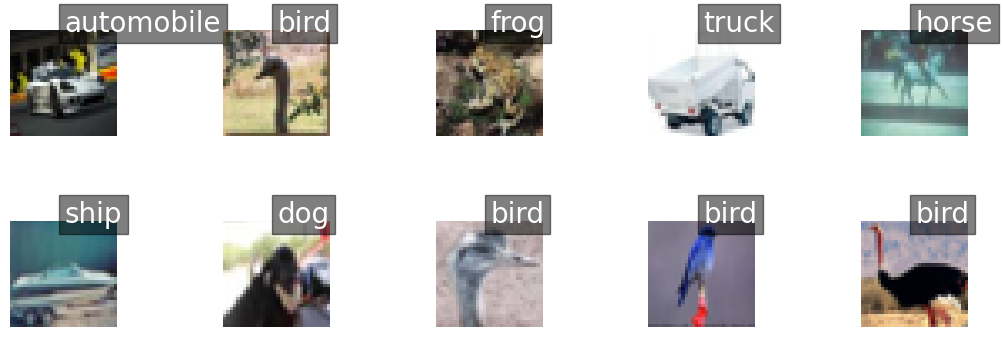

In [69]:
fig,axs = plt.subplots(2,5,figsize=(10,4))

for ax in axs.flatten():
    randidx = np.random.randint(0, len(cdata.data))

    pic = cdata.data[randidx,:,:,:]
    label = cdata.classes[cdata.targets[randidx]]

    ax.imshow(pic)
    ax.text(16,0, str(label), color='white', fontsize=20, bbox=dict(facecolor='black', alpha=0.5))
    ax.axis('off')

plt.tight_layout()
plt.show()


# Order the data, normalize it and put it in loaders

In [70]:
testdata, valdata, testlabels, vallabels = train_test_split(cdata_valtest.data, cdata_valtest.targets, test_size=0.5)

train_data_tensor = torch.tensor(cdata.data, dtype=torch.float32)
train_data_tensor = train_data_tensor.permute(0, 3, 1, 2) / 255.0 
train_labels_tensor = torch.tensor(cdata.targets, dtype=torch.long)

test_data_tensor = torch.tensor(testdata, dtype=torch.float32)
test_data_tensor = test_data_tensor.permute(0, 3, 1, 2) / 255.0
test_labels_tensor = torch.tensor(testlabels, dtype=torch.long)

val_data_tensor = torch.tensor(valdata, dtype=torch.float32)
val_data_tensor = val_data_tensor.permute(0, 3, 1, 2) / 255.0
val_labels_tensor = torch.tensor(vallabels, dtype=torch.long)

train_data = TensorDataset(train_data_tensor, train_labels_tensor)
test_data = TensorDataset(test_data_tensor, test_labels_tensor)
val_data = TensorDataset(val_data_tensor, val_labels_tensor)

batchsize = BATCHSIZE
train_loader = DataLoader(train_data, batch_size=batchsize, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0], shuffle=False, drop_last=True)
val_loader = DataLoader(val_data, batch_size=val_data.tensors[0].shape[0], shuffle=False, drop_last=True)

print(train_loader.dataset.tensors[0].shape)
print(train_loader.dataset.tensors[1].shape)
print(test_loader.dataset.tensors[0].shape)
print(test_loader.dataset.tensors[1].shape)
print(val_loader.dataset.tensors[0].shape)
print(val_loader.dataset.tensors[1].shape)

torch.Size([50000, 3, 32, 32])
torch.Size([50000])
torch.Size([5000, 3, 32, 32])
torch.Size([5000])
torch.Size([5000, 3, 32, 32])
torch.Size([5000])


# Do we need to normalize the images?

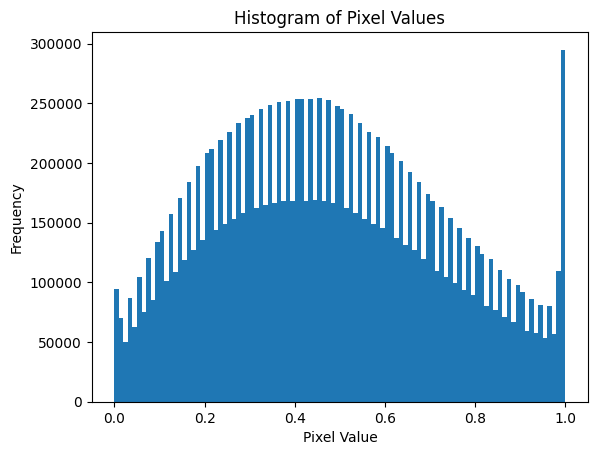

In [71]:
for X,y in val_loader:
    X, y = X.to(device), y.to(device)

plt.hist(X.cpu().numpy().flatten(), bins=100)
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram of Pixel Values')
plt.show()

# Obviously already normalised, we just did it.

# Create the model

In [72]:
def makeTheNet():

    class cidar10ae(nn.Module):
        def __init__(self):
            super().__init__()

            self.enc_conv1 = nn.Sequential(
                nn.Conv2d(3, 16, kernel_size=4, stride=2, padding=1),
                nn.LeakyReLU()
                #output = floor((32+2*1-4)/2)+1 = 16
            )

            self.enc_conv2 = nn.Sequential(
                nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
                nn.LeakyReLU()
                #output = floor((16+2*1-4)/2)+1 = 8
            )

            self.latent = nn.Sequential(            
                nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
                nn.LeakyReLU()
                # output = floor((8+2*1-4)/2)+1 = 4
            )

            self.dec_conv1 = nn.Sequential(
                nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
                nn.LeakyReLU()
            )

            self.dec_conv2 = nn.Sequential(
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
                nn.LeakyReLU()
            )

            self.output = nn.Sequential(
                nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=1)
                # do we need non linearity here? I don't think so
            )
            
        def forward(self, x):
            encoded1 = self.enc_conv1(x)
            encoded2 = self.enc_conv2(encoded1)
            latent = self.latent(encoded2)
            decoded1 = self.dec_conv1(latent)
            decoded2 = self.dec_conv2(decoded1)
            x = self.output(decoded2)
            
            return x
        
    net = cidar10ae()
    
    lossfun = nn.MSELoss()

    optimizer = torch.optim.Adam(net.parameters(), lr=LR)

    return net, lossfun, optimizer

# Test the model

In [73]:
net, lossfun, optimizer = makeTheNet()
net.to(device)  # Move the model to the same device as the input tensor

X, y = next(iter(train_loader))
X, y = X.to(device), y.to(device)  # Move input and labels to the same device
yHat = net(X)

summary(net, (3, 32, 32), device=str(device))  # Ensure summary uses the correct device

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 16, 16]             784
         LeakyReLU-2           [-1, 16, 16, 16]               0
            Conv2d-3             [-1, 32, 8, 8]           8,224
         LeakyReLU-4             [-1, 32, 8, 8]               0
            Conv2d-5             [-1, 64, 4, 4]          32,832
         LeakyReLU-6             [-1, 64, 4, 4]               0
   ConvTranspose2d-7             [-1, 32, 8, 8]          32,800
         LeakyReLU-8             [-1, 32, 8, 8]               0
   ConvTranspose2d-9           [-1, 16, 16, 16]           8,208
        LeakyReLU-10           [-1, 16, 16, 16]               0
  ConvTranspose2d-11            [-1, 3, 32, 32]             771
Total params: 83,619
Trainable params: 83,619
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/ba

# Create a function that trains the model

In [74]:
def function2trainTheModel(epochs = 10, val=False):
    epochs = epochs

    net, lossfun, optimizer = makeTheNet()

    net.to(device)

    trainLoss = torch.zeros(epochs)
    testLoss = torch.zeros(epochs)
    valLoss = torch.zeros(epochs)

    for epoch in range(epochs):
        net.train()

        batchLoss = []
        
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            yHat = net(X)
            loss = lossfun(yHat, X)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchLoss.append(loss.item())

        trainLoss[epoch] = np.mean(batchLoss)

        net.eval()
        X,y = next(iter(test_loader))
        X, y = X.to(device), y.to(device)

        with torch.no_grad():
            yHat = net(X)
            loss = lossfun(yHat, X)

        testLoss[epoch] = loss.item()

        if val:
            X,y = next(iter(val_loader))
            X, y = X.to(device), y.to(device)

            with torch.no_grad():
                yHat = net(X)
                loss = lossfun(yHat, X)

            valLoss[epoch] = loss.item()

    return net, trainLoss, testLoss, valLoss

# Test the training function

In [75]:
net, trainLoss, testLoss, valLoss = function2trainTheModel(epochs=3, val=True)

# Train the model

In [76]:
net, trainLoss, testLoss, valLoss = function2trainTheModel(epochs=15, val=False)

# Graph the results

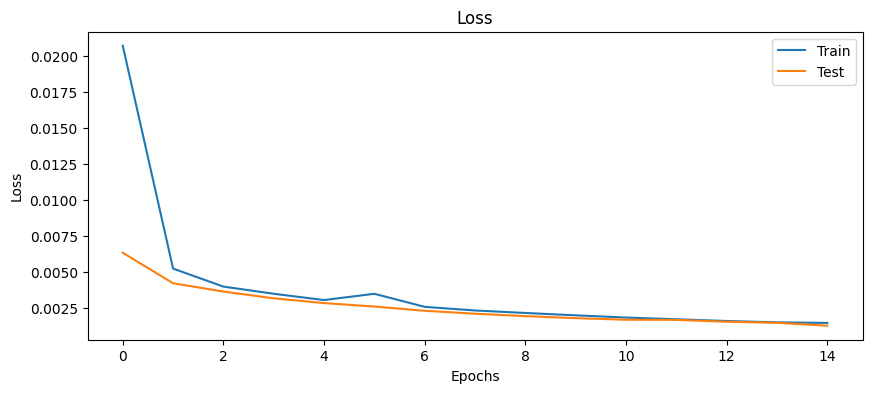

In [77]:
fix, axs = plt.subplots(1,1, figsize=(10,4))

axs.plot(trainLoss)
axs.plot(testLoss)
axs.set_title(f'Loss')
axs.set_xlabel('Epochs')
axs.set_ylabel('Loss')
axs.legend(['Train', 'Test'])

# Train the "final" model

In [78]:
# Initialize accumulators for averaging
avg_trainLoss = torch.zeros(15)
avg_testLoss = torch.zeros(15)
avg_valLoss = torch.zeros(15)

# Loop 5 times
for _ in range(5):
    net, trainLoss, testLoss, valLoss = function2trainTheModel(epochs=15, val=True)
    avg_trainLoss += trainLoss
    avg_testLoss += testLoss
    avg_valLoss += valLoss

# Calculate the average
avg_trainLoss /= 5
avg_testLoss /= 5
avg_valLoss /= 5

# Graph the results

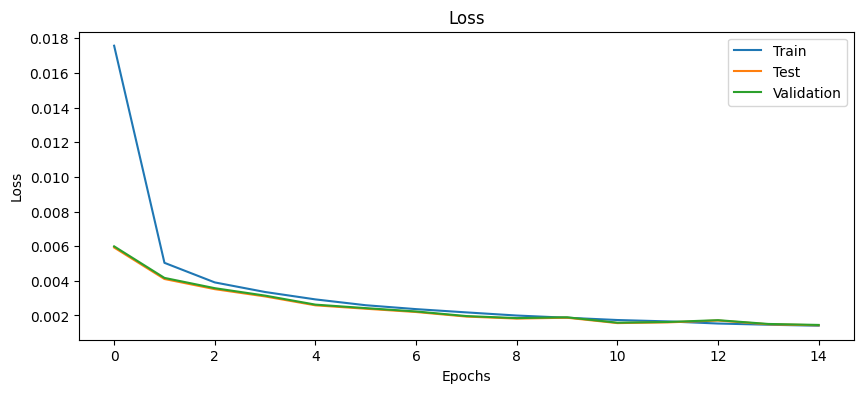

In [79]:
fix, axs = plt.subplots(1,1, figsize=(10,4))

axs.plot(avg_trainLoss)
axs.plot(avg_testLoss)
axs.plot(avg_valLoss)
axs.set_title(f'Loss')
axs.set_xlabel('Epochs')
axs.set_ylabel('Loss')
axs.legend(['Train', 'Test', 'Validation'])

# Show the difference between the input and output

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06100272..0.74097].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.064775296..1.0962204].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.042173147..0.87123483].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.020686604..0.93477684].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03517282..0.98422945].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0367352..1.0269442].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.

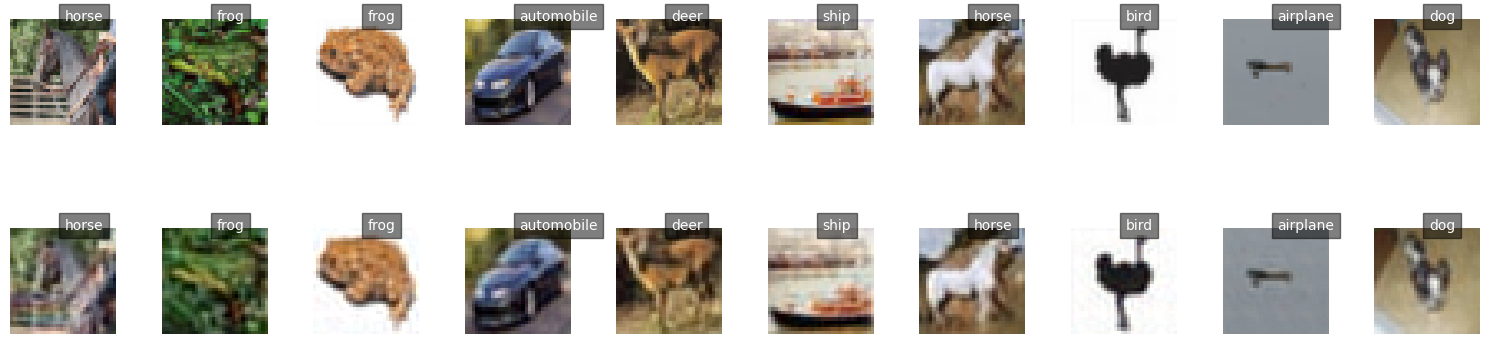

In [81]:
for X,y in val_loader:
    X, y = X.to(device), y.to(device)
    yHat = net(X)
    
# show some images
fig, axs = plt.subplots(2, 10, figsize=(15, 5))

for i in range(10):
    label = cdata.classes[y[i].cpu().numpy()]
    axs[0,i].imshow(X[i].permute(1, 2, 0).cpu())
    axs[0,i].text(16, 0, label, color='white', fontsize=10, bbox=dict(facecolor='black', alpha=0.5))
    axs[0,i].axis('off')
    axs[1,i].imshow(yHat[i].detach().permute(1, 2, 0).cpu())
    axs[1,i].text(16, 0, label, color='white', fontsize=10, bbox=dict(facecolor='black', alpha=0.5))
    axs[1,i].axis('off')
plt.tight_layout()
plt.show()